In [1]:
import pandas as pd
from narwhals.stable.v2 import exclude

pd.options.display.max_columns = None
df = pd.read_csv("data/student_placement_prediction_dataset_2026.csv")

In [2]:
df.head(10)

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,hackathons_participated,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,57.707166,59.070073,4,1,184,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,59.197085,78.976419,0,2,539,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,92.104885,80.603331,0,2,568,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,83.411798,64.187246,1,1,550,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,88.956331,56.163678,1,4,833,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16
5,6,22,Male,7.44,CSE,Tier 2,1,5,1,49.758865,45.252593,51.881728,69.984592,3,8,77,66.138578,82.038139,0,54.150818,69.210022,No,9.1,3.4,Placed,11.78
6,7,22,Male,7.54,CSE,Tier 3,0,2,2,68.816160,63.787196,79.969910,76.546475,0,2,154,56.207496,72.267945,1,79.323137,26.179746,No,8.9,3.1,Not Placed,0.00
7,8,24,Female,6.86,Civil,Tier 3,3,4,2,87.471971,56.962395,58.138781,66.579454,2,8,98,89.189601,79.128528,1,23.394036,36.903695,Yes,8.8,1.6,Not Placed,0.00
8,9,19,Male,8.52,Mechanical,Tier 2,2,5,0,100.000000,93.987115,75.165144,87.737986,0,7,269,64.035703,89.884948,0,68.598878,42.647145,No,8.5,4.2,Placed,16.33
9,10,20,Female,8.07,Civil,Tier 2,2,2,2,93.421972,71.379374,57.215196,58.628985,0,6,747,72.217117,88.901107,0,86.199176,1.371853,No,5.9,4.5,Placed,16.17


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

student_id — ID студента

age — Возраст

gender — Пол

cgpa — CGPA (средний балл)

branch — Специальность / Направление

college_tier — Уровень колледжа (Tier)

internships_count — Количество стажировок

projects_count — Количество проектов

certifications_count — Количество сертификатов

coding_skill_score — Уровень навыков программирования

aptitude_score — Оценка способностей (aptitude test)

communication_skill_score — Навыки коммуникации

logical_reasoning_score — Логическое мышление

hackathons_participated — Участие в хакатонах

github_repos — Репозитории на GitHub

linkedin_connections — Связи на LinkedIn

mock_interview_score — Оценка за пробное собеседование

attendance_percentage — Процент посещаемости

backlogs — Количество долгов / пересдач

extracurricular_score — Внеучебная активность

leadership_score — Лидерские качества

volunteer_experience — Волонтёрский опыт

sleep_hours — Часы сна в сутки

study_hours_per_day — Часы учёбы в день

placement_status — Статус трудоустройства

salary_package_lpa — Зарплата (в LPA — lakhs per annum)

*Для классификации:* placement_status - трудоустроился или нет

*Для регрессии:* salary_package_lpa - зарплата

In [4]:
# КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['gender', 'branch', 'college_tier', 'volunteer_experience', 'placement_status']

le = LabelEncoder()

for col in categorical_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])

print(df[['placement_status', 'placement_status_encoded']].head())

  placement_status  placement_status_encoded
0       Not Placed                         0
1       Not Placed                         0
2           Placed                         1
3       Not Placed                         0
4           Placed                         1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   student_id                    100000 non-null  int64  
 1   age                           100000 non-null  int64  
 2   gender                        100000 non-null  object 
 3   cgpa                          100000 non-null  float64
 4   branch                        100000 non-null  object 
 5   college_tier                  100000 non-null  object 
 6   internships_count             100000 non-null  int64  
 7   projects_count                100000 non-null  int64  
 8   certifications_count          100000 non-null  int64  
 9   coding_skill_score            100000 non-null  float64
 10  aptitude_score                100000 non-null  float64
 11  communication_skill_score     100000 non-null  float64
 12  logical_reasoning_score       100000 non-null

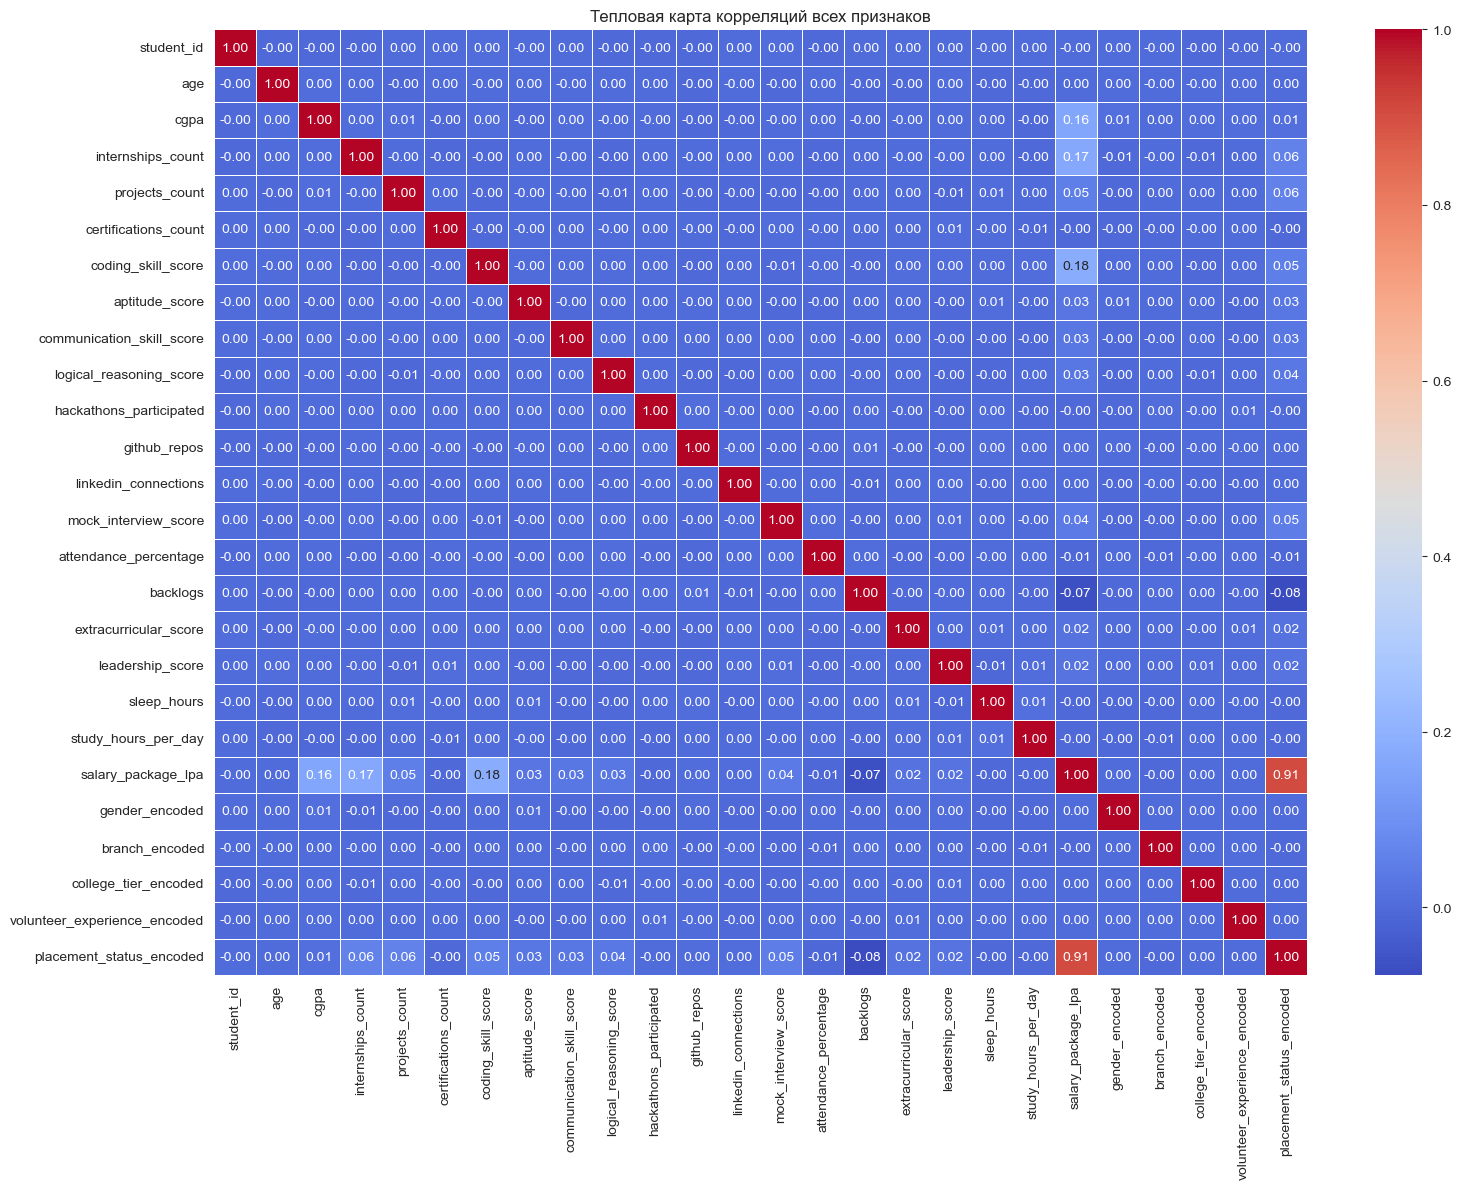

In [12]:
# КОРРЕЛЯЦИОННАЯ МАТРИЦА И ТЕПЛОВАЯ КАРТА
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['int32', 'int64', 'float64']).copy()

plt.figure(figsize=(16, 12))
corr_matrix = numeric_df.corr(method='spearman') # можно добавить method='spearman'

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Тепловая карта корреляций всех признаков')
plt.tight_layout()
plt.show()

Самые заметные корреляции с placement_status_encoded (трудоустройство):

- salary_package_lpa → +0.98
- (это логично: если человек устроился — у него есть зарплата, если нет — 0)
- internships_count → +0.05 - Количество стажировок
- projects_count → +0.06 - Количество проектов
- coding_skill_score → +0.05 - Навыки программирования
- mock_interview_score → +0.04 - Результаты мок-интервью
- cgpa → +0.06 - Средний балл за весь период обучения
- aptitude_score → +0.03 - Средний рейтинг за тест
- backlogs → -0.08 (чем больше долгов — тем хуже шансы на трудоустройство)


Корреляции с salary_package_lpa (зарплата):

- internships_count → +0.11 - Количества стажировок
- coding_skill_score → +0.11 - Навыки программирования
- cgpa → +0.08 - Средний балл за весь период обучения
- projects_count → +0.06 - Количества проектов
- mock_interview_score → +0.04 - Результаты интервью


Корреляция входных признаков с трудоустройством (по убыванию):
internships_count               0.063489
projects_count                  0.060964
coding_skill_score              0.050773
mock_interview_score            0.046058
logical_reasoning_score         0.036332
communication_skill_score       0.032242
aptitude_score                  0.031690
leadership_score                0.022170
extracurricular_score           0.020100
cgpa                            0.012067
github_repos                    0.004807
linkedin_connections            0.003223
college_tier_encoded            0.002005
gender_encoded                  0.001244
volunteer_experience_encoded    0.001240
hackathons_participated         0.001236
age                             0.000858
student_id                     -0.000821
study_hours_per_day            -0.001426
certifications_count           -0.003806
branch_encoded                 -0.004320
sleep_hours                    -0.004692
attendance_percentage          -0.0

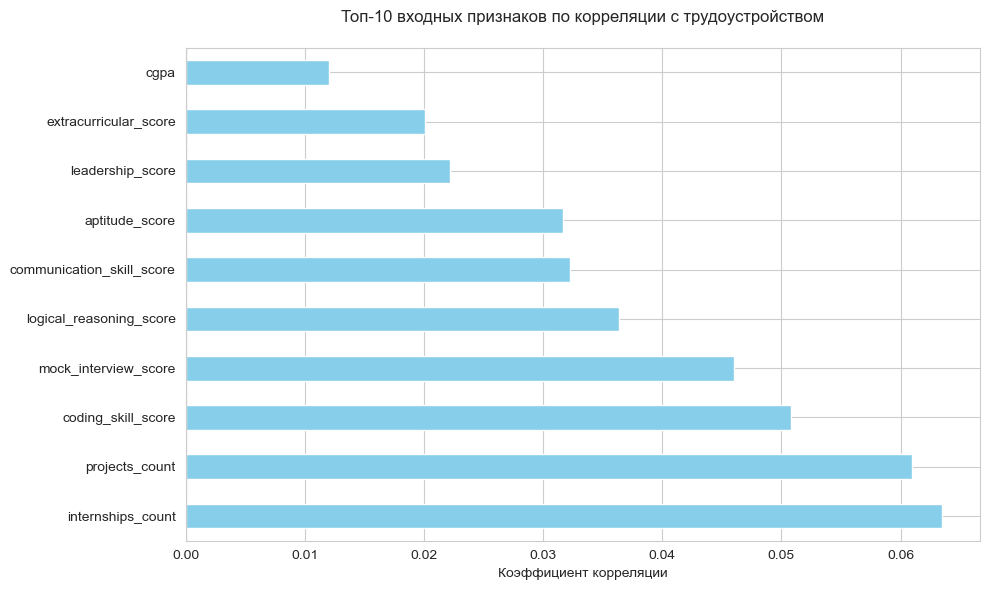

In [9]:
# КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ТРУДОУСТРОЙСТВОМ

target = 'placement_status_encoded'

exclude_cols = ['placement_status_encoded', 'salary_package_lpa']

features_df = numeric_df.drop(columns=exclude_cols, errors='ignore')
correlations = features_df.corrwith(numeric_df[target]).sort_values(ascending=False)

print("Корреляция входных признаков с трудоустройством (по убыванию):")
print(correlations)

plt.figure(figsize=(10, 6))
correlations.head(10).plot(kind='barh', color='skyblue')
plt.title('Топ-10 входных признаков по корреляции с трудоустройством\n')
plt.xlabel('Коэффициент корреляции')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

Корреляция входных признаков с зарплатой (по убыванию):
internships_count               0.063489
projects_count                  0.060964
coding_skill_score              0.050773
mock_interview_score            0.046058
logical_reasoning_score         0.036332
communication_skill_score       0.032242
aptitude_score                  0.031690
leadership_score                0.022170
extracurricular_score           0.020100
cgpa                            0.012067
github_repos                    0.004807
linkedin_connections            0.003223
college_tier_encoded            0.002005
gender_encoded                  0.001244
volunteer_experience_encoded    0.001240
hackathons_participated         0.001236
age                             0.000858
student_id                     -0.000821
study_hours_per_day            -0.001426
certifications_count           -0.003806
branch_encoded                 -0.004320
sleep_hours                    -0.004692
attendance_percentage          -0.008350
b

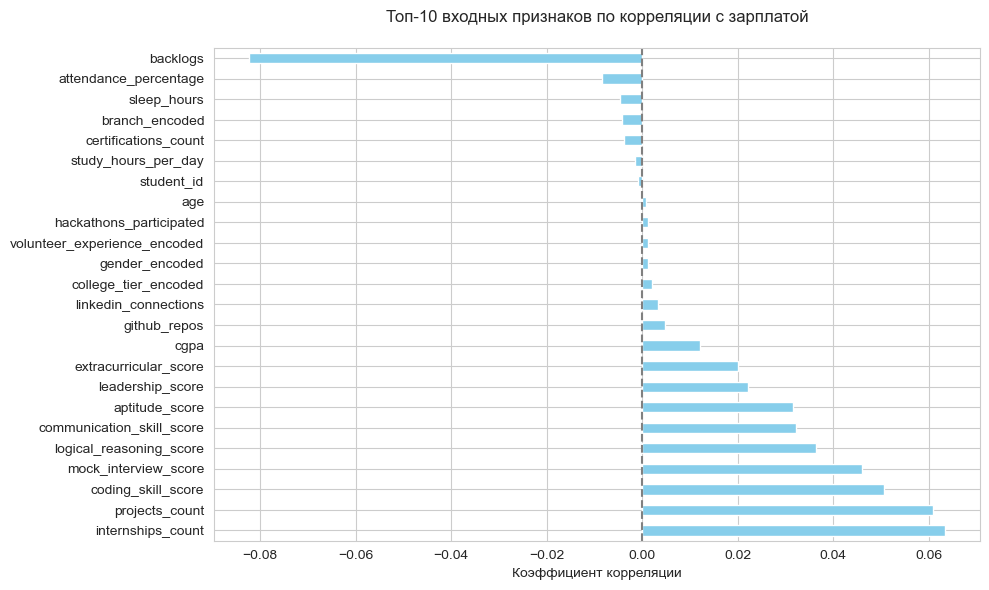

In [13]:
# КОРРЕЛЯЦИЯ ПРИЗНАКОВ С ЗАРПЛАТОЙ

target = 'placement_status_encoded'

exclude_cols = ['salary_package_lpa', 'salary_package_lpa', 'placement_status_encoded']

features_df = numeric_df.drop(columns=exclude_cols, errors='ignore')
correlations = features_df.corrwith(numeric_df[target]).sort_values(ascending=False)

print("Корреляция входных признаков с зарплатой (по убыванию):")
print(correlations)

plt.figure(figsize=(10, 6))
correlations.head(50).plot(kind='barh', color='skyblue')
plt.title('Топ-10 входных признаков по корреляции с зарплатой\n')
plt.xlabel('Коэффициент корреляции')
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

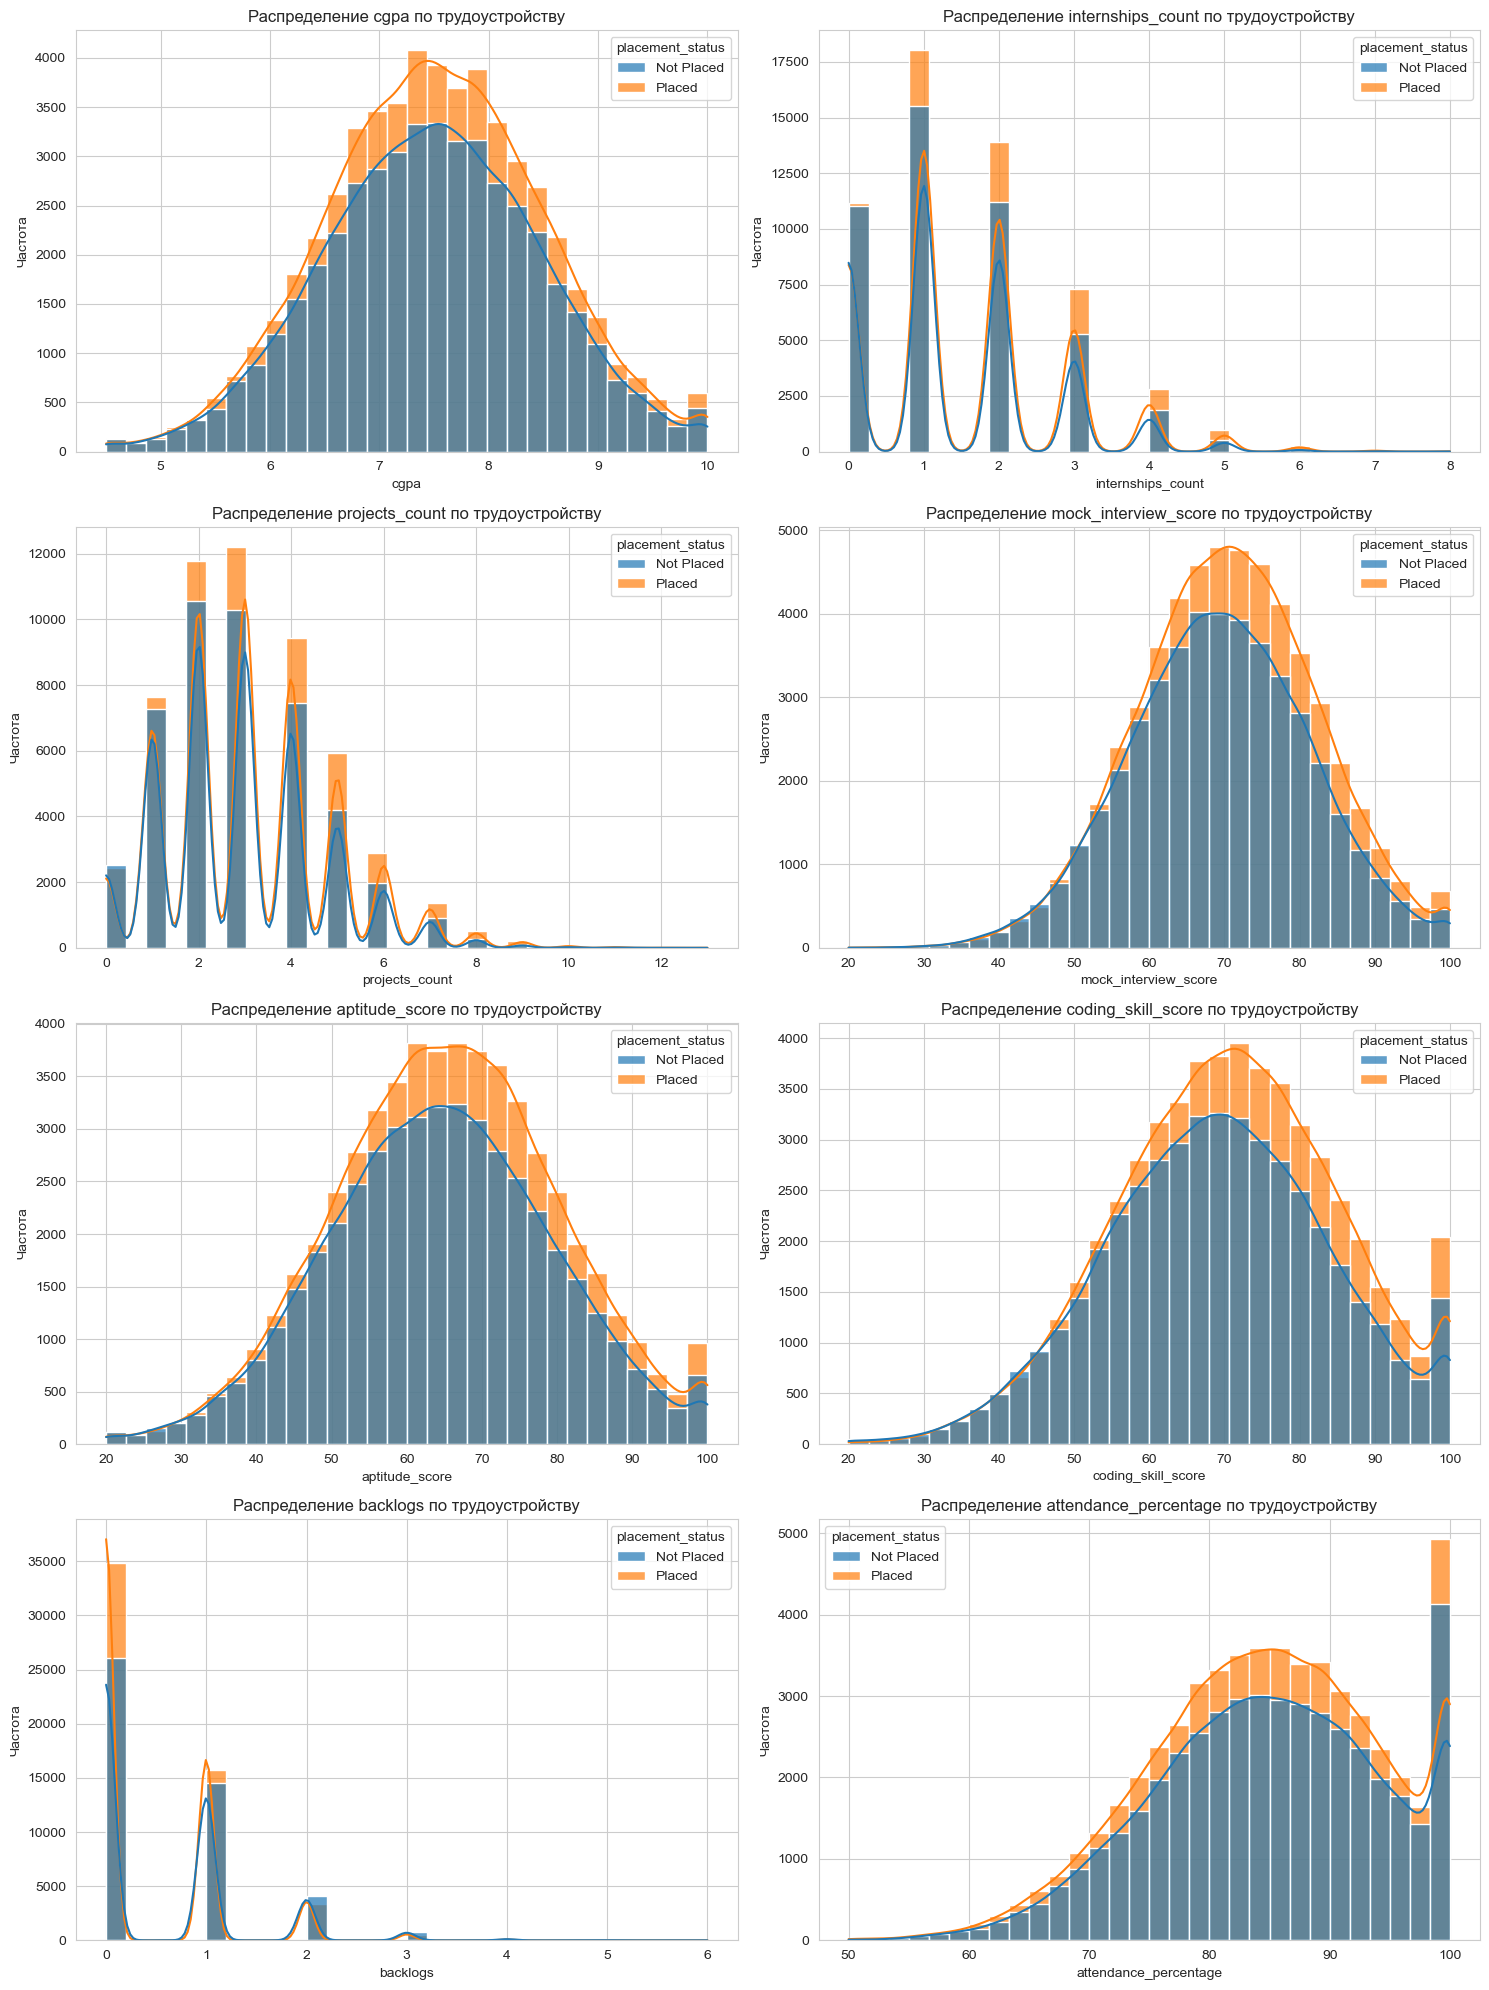

In [14]:
# ГРАФИКИ РАСПРЕДЕЛЕНИЯ ПРИЗНАКОВ

important_features = ['cgpa', 'internships_count', 'projects_count', 'mock_interview_score',
                      'aptitude_score', 'coding_skill_score', 'backlogs', 'attendance_percentage']

plt.figure(figsize=(15, 20))

for i, feature in enumerate(important_features, 1):
    plt.subplot(4, 2, i)
    sns.histplot(data=df, x=feature, hue='placement_status', kde=True, bins=30, alpha=0.7)
    plt.title(f'Распределение {feature} по трудоустройству')
    plt.xlabel(feature)
    plt.ylabel('Частота')

plt.tight_layout()
plt.show()

Трудоустраиваются те, кто хорошо учится, делает проекты, а также **БОЛЬШЕ** ходит по собесам и лучше кодит